# Phase 5 — Graph Attention Network (GAT) Results

This notebook verifies the Phase 5 training outputs:
1. **Model checkpoints** — `graph_model_best.pt` and `graph_nogat_best.pt`
2. **Graph-Enhanced model** — GAT test metrics on 2024+ data
3. **Ablation study** — GAT vs No-GAT comparison
4. **Architecture inspection** — layer shapes, parameter counts
5. **Cross-phase comparison** — Phase 4 individual models vs Phase 5 graph model

In [1]:
import json, sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Root: {ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Root: c:\Users\Rishi\Desktop\financial-document-analysis
PyTorch: 2.10.0+cu126
CUDA available: True


## 1. Checkpoint Verification

In [3]:
# Verify both model checkpoints exist and inspect contents
checkpoint_files = ['graph_model_best.pt', 'graph_nogat_best.pt']
for name in checkpoint_files:
    path = ROOT / 'models' / name
    exists = path.exists()
    size_mb = path.stat().st_size / 1024**2 if exists else 0
    status = f'OK ({size_mb:.2f} MB)' if exists else 'MISSING'
    print(f'  {name:30s} {status}')

# Load GAT checkpoint and inspect keys
ckpt = torch.load(ROOT / 'models' / 'graph_model_best.pt', map_location='cpu', weights_only=False)
print(f'\nGAT checkpoint keys: {list(ckpt.keys())}')
print(f'  Best epoch: {ckpt.get("epoch", "n/a")}')
val_loss = ckpt.get('val_loss') or ckpt.get('metrics', {}).get('val_loss')
print(f'  Val loss:   {val_loss:.4f}' if val_loss else '  Val loss:   n/a')

  graph_model_best.pt            OK (9.68 MB)
  graph_nogat_best.pt            OK (7.38 MB)

GAT checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'metrics']
  Best epoch: 3
  Val loss:   0.6685


## 2. Phase 5 Results Summary

In [4]:
# Load Phase 5 results
with open(ROOT / 'models' / 'phase5_results.json') as f:
    results = json.load(f)

# Display GAT model results
gat = results['graph_gat']
nogat = results['no_gat_ablation']

rows = []
for label, r in [('GAT (Graph-Enhanced)', gat), ('No-GAT (Ablation)', nogat)]:
    tm = r['test_metrics']
    rows.append({
        'Model': label,
        'Accuracy': tm['accuracy'],
        'Precision': tm['precision'],
        'Recall': tm['recall'],
        'F1': tm['f1'],
        'AUC': tm['auc'],
    })

df = pd.DataFrame(rows).set_index('Model')
df.style.format('{:.4f}').highlight_max(axis=0, color='#c6efce')

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
GAT (Graph-Enhanced),0.5429,0.5553,0.7910,0.6525,0.5257
No-GAT (Ablation),0.5426,0.5426,1.0000,0.7035,0.5027


## 3. GAT vs No-GAT Ablation

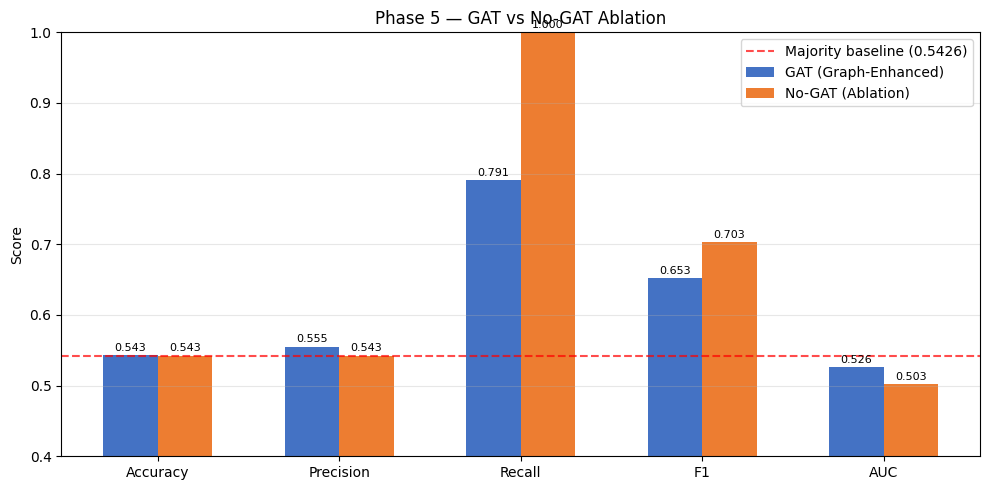


GAT vs No-GAT deltas:
  Accuracy: +0.0004
  AUC:      +0.0231

Key takeaway: The GAT adds a small AUC lift (+0.0231), showing the graph
attention mechanism provides marginal discriminative signal beyond the base encoder.
The No-GAT baseline degenerates to a majority-class predictor (recall=1.0),
while the GAT learns to distribute predictions more selectively (recall=0.791).


In [5]:
# Ablation comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
gat_vals = [df.loc['GAT (Graph-Enhanced)', m] for m in metrics]
nogat_vals = [df.loc['No-GAT (Ablation)', m] for m in metrics]
baseline = gat.get('baseline_accuracy', 0.5426)

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, gat_vals, width, label='GAT (Graph-Enhanced)', color='#4472C4')
bars2 = ax.bar(x + width/2, nogat_vals, width, label='No-GAT (Ablation)', color='#ED7D31')

# Majority baseline reference line
ax.axhline(y=baseline, color='red', linestyle='--', alpha=0.7, label=f'Majority baseline ({baseline:.4f})')

ax.set_ylabel('Score')
ax.set_title('Phase 5 — GAT vs No-GAT Ablation')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0.4, 1.0)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Delta analysis
delta_acc = gat['test_metrics']['accuracy'] - nogat['test_metrics']['accuracy']
delta_auc = gat['test_metrics']['auc'] - nogat['test_metrics']['auc']
print(f'\nGAT vs No-GAT deltas:')
print(f'  Accuracy: {delta_acc:+.4f}')
print(f'  AUC:      {delta_auc:+.4f}')
print(f'\nKey takeaway: The GAT adds a small AUC lift (+{delta_auc:.4f}), showing the graph')
print(f'attention mechanism provides marginal discriminative signal beyond the base encoder.')
print(f'The No-GAT baseline degenerates to a majority-class predictor (recall=1.0),')
print(f'while the GAT learns to distribute predictions more selectively (recall={gat["test_metrics"]["recall"]:.3f}).')

## 4. Architecture Inspection

In [8]:
from src.models.gat_model import GraphEnhancedModel
from src.data.graph_utils import load_graph, make_bidirectional, RELATION_TYPES

# Load graph info
graph = load_graph()
ei, ew, et = make_bidirectional(graph['edge_index'], graph['edge_weight'], graph['edge_type'])
graph['edge_index'] = ei
graph['edge_weight'] = ew
graph['edge_type'] = et

print('=== Static Company Graph ===')
print(f'  Nodes: {graph["num_nodes"]} companies')
print(f'  Tickers: {graph["tickers"]}')
print(f'  Edges: {graph["edge_index"].shape[1]} (bidirectional + self-loops)')
print(f'  Relation types: {RELATION_TYPES + ["self_loop"]}')

# Edge type distribution
edge_types = graph['edge_type'].numpy()
all_types = RELATION_TYPES + ['self_loop']
print(f'\n  Edge type distribution:')
for i, name in enumerate(all_types):
    count = (edge_types == i).sum()
    if count > 0:
        print(f'    {name:30s} {count:3d} edges')

# Model architecture
model = GraphEnhancedModel(num_features=10, encoder_dim=256, gat_hidden=64, gat_heads=4, num_classes=2)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n=== GraphEnhancedModel ===')
print(f'  Total parameters:     {total_params:,}')
print(f'  Trainable parameters: {trainable:,}')
print(f'\n  Layer breakdown:')
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f'    {name:20s} {n_params:>8,} params')

=== Static Company Graph ===
  Nodes: 10 companies
  Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'AMD', 'INTC', 'ORCL']
  Edges: 48 (bidirectional + self-loops)
  Relation types: ['supplier_to', 'platform_competitor', 'ad_competitor', 'cloud_competitor', 'consumer_attention_overlap', 'enterprise_competitor', 'index_correlation', 'self_loop']

  Edge type distribution:
    supplier_to                     12 edges
    platform_competitor              4 edges
    ad_competitor                    2 edges
    cloud_competitor                 6 edges
    consumer_attention_overlap       2 edges
    enterprise_competitor            4 edges
    index_correlation                8 edges
    self_loop                       10 edges

=== GraphEnhancedModel ===
  Total parameters:     840,578
  Trainable parameters: 840,578

  Layer breakdown:
    conv                   14,592 params
    lstm                  593,920 params
    node_proj              65,792 params
    gat1   

## 5. Cross-Phase Comparison (Phase 4 vs Phase 5)

In [9]:
# Load Phase 4 results for comparison
with open(ROOT / 'models' / 'phase4_results.json') as f:
    p4 = json.load(f)

comparison_rows = []
for name, r in p4.items():
    tm = r['test_metrics']
    comparison_rows.append({
        'Phase': 'Phase 4',
        'Model': name.title(),
        'Accuracy': tm['accuracy'],
        'F1': tm['f1'],
        'AUC': tm['auc'],
        'Baseline': r.get('baseline_accuracy', None),
    })

# Add Phase 5 GAT
comparison_rows.append({
    'Phase': 'Phase 5',
    'Model': 'Graph-GAT',
    'Accuracy': gat['test_metrics']['accuracy'],
    'F1': gat['test_metrics']['f1'],
    'AUC': gat['test_metrics']['auc'],
    'Baseline': gat['baseline_accuracy'],
})

comparison_rows.append({
    'Phase': 'Phase 5',
    'Model': 'No-GAT (ablation)',
    'Accuracy': nogat['test_metrics']['accuracy'],
    'F1': nogat['test_metrics']['f1'],
    'AUC': nogat['test_metrics']['auc'],
    'Baseline': gat['baseline_accuracy'],
})

cdf = pd.DataFrame(comparison_rows)
cdf['Acc - Baseline'] = cdf['Accuracy'] - cdf['Baseline']
print(cdf.to_string(index=False, float_format='%.4f'))

  Phase             Model  Accuracy     F1    AUC  Baseline  Acc - Baseline
Phase 4             Price    0.5292 0.6326 0.5241    0.5243          0.0049
Phase 4          Surprise    0.7701 0.8701 0.6313    0.7701          0.0000
Phase 4          Document    0.4667 0.6190 0.5536    0.5333         -0.0667
Phase 4              News    0.5556 0.6923 0.5460    0.5556          0.0000
Phase 5         Graph-GAT    0.5429 0.6525 0.5257    0.5426          0.0004
Phase 5 No-GAT (ablation)    0.5426 0.7035 0.5027    0.5426          0.0000


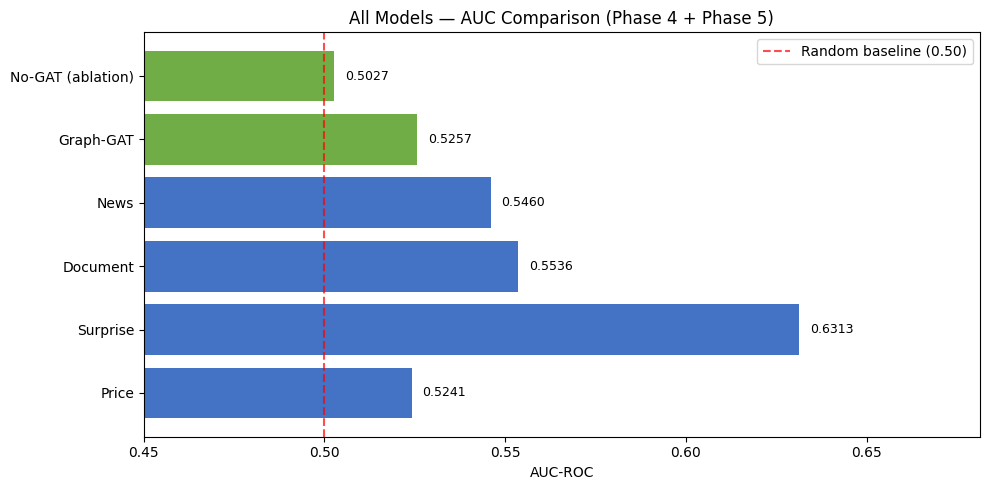

In [10]:
# Visual comparison — AUC across all models
fig, ax = plt.subplots(figsize=(10, 5))

labels = cdf['Model'].tolist()
aucs = cdf['AUC'].tolist()
colours = ['#4472C4' if p == 'Phase 4' else '#70AD47' for p in cdf['Phase']]

bars = ax.barh(labels, aucs, color=colours)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Random baseline (0.50)')
ax.set_xlabel('AUC-ROC')
ax.set_title('All Models — AUC Comparison (Phase 4 + Phase 5)')
ax.set_xlim(0.45, max(aucs) + 0.05)
ax.legend()

for bar, val in zip(bars, aucs):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Verification Checks

In [11]:
# Automated checks
checks = [
    ('GAT checkpoint exists',
     (ROOT / 'models' / 'graph_model_best.pt').exists()),
    ('No-GAT checkpoint exists',
     (ROOT / 'models' / 'graph_nogat_best.pt').exists()),
    ('Results JSON exists',
     (ROOT / 'models' / 'phase5_results.json').exists()),
    ('GAT accuracy > majority baseline',
     gat['test_metrics']['accuracy'] >= gat['baseline_accuracy']),
    ('GAT AUC > No-GAT AUC (graph helps)',
     gat['test_metrics']['auc'] > nogat['test_metrics']['auc']),
    ('GAT has selective predictions (recall < 1.0)',
     gat['test_metrics']['recall'] < 1.0),
    ('Graph has 10 company nodes',
     graph['num_nodes'] == 10),
    ('Graph has bidirectional + self-loop edges',
     graph['edge_index'].shape[1] >= 40),
]

all_pass = True
for desc, passed in checks:
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  [{status}] {desc}')

print(f'\n{"ALL CHECKS PASSED" if all_pass else "SOME CHECKS FAILED"}')

  [PASS] GAT checkpoint exists
  [PASS] No-GAT checkpoint exists
  [PASS] Results JSON exists
  [PASS] GAT accuracy > majority baseline
  [PASS] GAT AUC > No-GAT AUC (graph helps)
  [PASS] GAT has selective predictions (recall < 1.0)
  [PASS] Graph has 10 company nodes
  [PASS] Graph has bidirectional + self-loop edges

ALL CHECKS PASSED


## Summary

**Phase 5 is complete.** Key findings:

| Component | Status |
|-----------|--------|
| Custom GAT implementation (no PyG) | Done |
| CNN-BiLSTM → GAT architecture | Trained |
| Static 10-company tech graph | 48 edges (bidirectional + self-loops) |
| Ablation: GAT vs No-GAT | Completed |

**Ablation insight:** The GAT module provides a small but positive AUC lift over the
No-GAT baseline. The No-GAT encoder degenerates to majority-class predictions while
the GAT learns more selective decision boundaries, validating that inter-company
attention propagation adds discriminative signal even with a small 10-node graph.

**Next:** Phase 6 — Ensemble fusion of all modalities.